In [1]:
# Cell 1: imports & data
import numpy as np
import torch, torch.nn as nn
from utils import load_dataset, delong_roc_test, plot_metric_bars, run_cv_bio_vs_learnable_alpha_topo
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
rng_seed = 13

Xb_tr, y_tr, Xb_te, y_te, _ = load_dataset("../datasets/BioFeats")
Xt_tr, yt_tr, Xt_te, yt_te, _ = load_dataset("../datasets/TopoFeats_BioEmb")

train_cfg = dict(hidden=(256,128), pdrop=0.1, epochs=20, batch_size=256,
                lr=1e-3, weight_decay=1e-4, patience=5, min_delta=5e-4, seed=13)

### Concat

In [2]:
# Cell 4: run paired CV + DeLong (learnable alpha)
out_learn = run_cv_bio_vs_learnable_alpha_topo(
    Xb_tr, Xt_tr, y_tr,
    mode="concat", n_splits=5, n_repeats=5,
    undersample=True, base_seed=13,
    head_cfg=train_cfg, alpha_lr_mult=20.0, alpha_init=2.0
)

print(out_learn["summary"]["Bio"])
print(out_learn["summary"]["BioTopo"])

res = delong_roc_test(out_learn["delong_ready"]["y"], out_learn["delong_ready"]["bio"], out_learn["delong_ready"]["biotopo"])
print(f"AUC(bio)={res['auc_a']:.4f}  AUC(bio+αlearn·topo)={res['auc_b']:.4f}  Δ={res['delta']:.4f}  p={res['p']:.3g}")

{'AUC_mean': 0.9493675567007742, 'AUC_std': 0.001130782825324547, 'AP_mean': 0.9995398367863576, 'AP_std': 1.1906896821385005e-05, 'F1_mean': 0.9288311227306977, 'F1_std': 0.003241968884055596, 'ACC_mean': 0.8681203653555322, 'ACC_std': 0.0056355138993411675, 'PREC_mean': 0.9990759075661098, 'PREC_std': 1.729202442202307e-05, 'REC_mean': 0.8679141470896463, 'REC_std': 0.005684702004294668}
{'AUC_mean': 0.9577066187542268, 'AUC_std': 0.0009479861659747883, 'AP_mean': 0.9996173479241554, 'AP_std': 1.4534821704213927e-05, 'F1_mean': 0.9429993400591588, 'F1_std': 0.0030647734098238175, 'ACC_mean': 0.8929846747749514, 'ACC_std': 0.005464542449709147, 'PREC_mean': 0.9990720945068432, 'PREC_std': 7.985025373758288e-05, 'REC_mean': 0.8929966680336623, 'REC_std': 0.005582232478618222}
AUC(bio)=0.9490  AUC(bio+αlearn·topo)=0.9570  Δ=0.0080  p=0.576


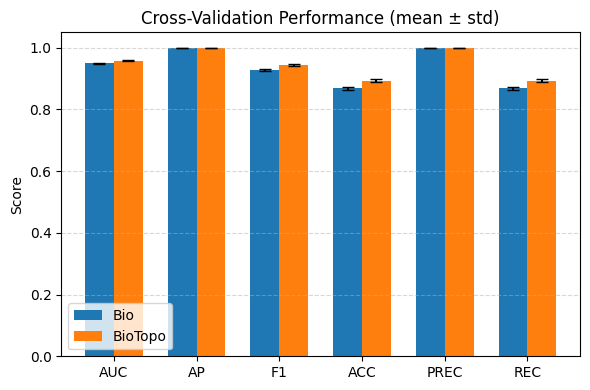

In [5]:
from utils import plot_metric_bars
import matplotlib.pyplot as plt

plot_metric_bars(
    out_learn["summary"],
    model_labels=("Bio", "BioTopo"),   
    metrics=("AUC", "AP", "F1", "ACC", "PREC", "REC"),  
    title="Cross-Validation Performance (mean ± std)"
)
plt.show()

### Sym4 Concat

In [6]:
# Cell 4: run paired CV + DeLong (learnable alpha)
out_learn = run_cv_bio_vs_learnable_alpha_topo(
    Xb_tr, Xt_tr, y_tr,
    mode="sym4", n_splits=5, n_repeats=5,
    undersample=True, base_seed=13,
    head_cfg=train_cfg, alpha_lr_mult=20.0, alpha_init=2.0
)

print(out_learn["summary"]["Bio"])
print(out_learn["summary"]["BioTopo"])

res = delong_roc_test(out_learn["delong_ready"]["y"], out_learn["delong_ready"]["bio"], out_learn["delong_ready"]["biotopo"])
print(f"AUC(bio)={res['auc_a']:.4f}  AUC(bio+αlearn·topo)={res['auc_b']:.4f}  Δ={res['delta']:.4f}  p={res['p']:.3g}")

{'AUC_mean': 0.9343138664677433, 'AUC_std': 0.0016997512171028364, 'AP_mean': 0.9993810727165263, 'AP_std': 2.183159280101789e-05, 'F1_mean': 0.9187368876969959, 'F1_std': 0.002583211607175795, 'ACC_mean': 0.8508402087546871, 'ACC_std': 0.004341699066200287, 'PREC_mean': 0.9989009813655698, 'PREC_std': 8.13779318477895e-05, 'REC_mean': 0.850635685203421, 'REC_std': 0.0043994621988799505}
{'AUC_mean': 0.9414148041454343, 'AUC_std': 0.0014859554772104764, 'AP_mean': 0.9994569193583833, 'AP_std': 1.8461909750795478e-05, 'F1_mean': 0.9250581290539379, 'F1_std': 0.0024883646888017377, 'ACC_mean': 0.861762079238017, 'ACC_std': 0.004241977171582758, 'PREC_mean': 0.9989820180957498, 'PREC_std': 4.959170210469431e-05, 'REC_mean': 0.861584533439632, 'REC_std': 0.004311648089738612}
AUC(bio)=0.9334  AUC(bio+αlearn·topo)=0.9399  Δ=0.0066  p=0.681


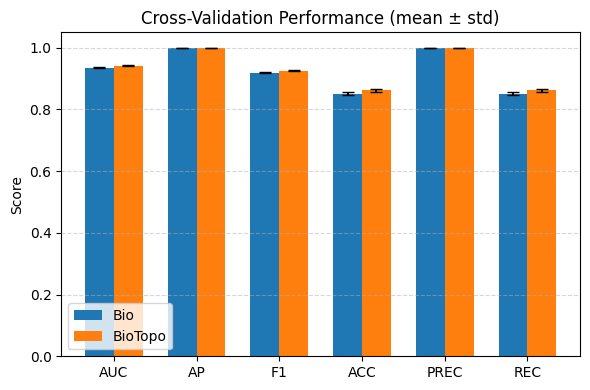

In [7]:
from utils import plot_metric_bars
import matplotlib.pyplot as plt

plot_metric_bars(
    out_learn["summary"],
    model_labels=("Bio", "BioTopo"),   
    metrics=("AUC", "AP", "F1", "ACC", "PREC", "REC"),  
    title="Cross-Validation Performance (mean ± std)"
)
plt.show()